In [37]:
# IMPORTS

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import RFECV, SelectFromModel

# Scipy
from scipy.stats import skew, kurtosis, shapiro, spearmanr, ks_2samp

# SHAP for model interpretability
import shap

In [38]:
# Load the dataset with encoding specified
df = pd.read_csv(r"C:/Users/srima/OneDrive/Desktop/INSY674/Individual Project 1/dataset.csv", encoding='latin-1')

# Display basic information about the dataset
print("Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)

df.columns

Dataset loaded successfully!

Dataset shape: (61745, 24)

First few rows:
  Country Name Country Code  \
0      Albania          ALB   
1      Albania          ALB   
2      Albania          ALB   
3      Albania          ALB   
4      Albania          ALB   

                                       Industry Name  Industry Code  \
0  151:Production, processing and preservation of...          151.0   
1  151:Production, processing and preservation of...          151.0   
2  151:Production, processing and preservation of...          151.0   
3  151:Production, processing and preservation of...          151.0   
4  151:Production, processing and preservation of...          151.0   

                        Series Name Series Code 1997 [YR1997] 1998 [YR1998]  \
0           001.Number of Exporters          A1            ..            ..   
1            002.Number of Entrants          A2            ..            ..   
2             003.Number of Exiters          A3            ..            ..

Index(['Country Name', 'Country Code', 'Industry Name', 'Industry Code',
       'Series Name', 'Series Code', '1997 [YR1997]', '1998 [YR1998]',
       '1999 [YR1999]', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]',
       '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]',
       '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]',
       '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]'],
      dtype='object')

In [39]:
#Deleting unusable columns
df1 = df.drop(['Country Code','Industry Code', 'Series Code'], axis=1)

df1.columns
#Transposing 'Series Name' values into separate headers/columns

# First, identify the year columns (adjust this based on your actual column names)
# For example, if your years are from 2000 to 2023:
years = [col for col in df1.columns if col not in ['Country Name', 'Series Name', 'Industry Name']]

df1_melted = df1.melt(
    id_vars=['Country Name', 'Series Name', 'Industry Name'],
    value_vars=years,
    var_name='Year',
    value_name='Value'
)

df1_pivot = df1_melted.pivot_table(
    index=['Country Name', 'Industry Name', 'Year'],
    columns='Series Name',
    values='Value',
    aggfunc='first'
).reset_index() 

df1_pivot.head()

df1_pivot.columns

Index(['Country Name', 'Industry Name', 'Year', '001.Number of Exporters',
       '002.Number of Entrants', '003.Number of Exiters',
       '004.Number of Surviving Entrants', '005.Number of Incumbents',
       '006.Export Value per Exporter: Mean',
       '007.Export Value per Exporter: Median',
       ...
       '089.Share of New Products in TEV of Incumbents: StDev.',
       '090.Share of New Products in TEV of Surviving Entrants: Mean',
       '091.Share of New Products in TEV of Surviving Entrants: Median',
       '092.Share of New Products in TEV of Surviving Entrants: StDev.',
       '093.Product Exit Rate of Incumbents: Mean',
       '094.Product Exit Rate of Incumbents: Median',
       '095.Product Exit Rate of Incumbents: StDev.',
       '096.Product Survival Rate of 2-year Incumbents: Mean',
       '097.Product Survival Rate of 2-year Incumbents: Median',
       '098.Product Survival Rate of 2-year Incumbents: StDev.'],
      dtype='object', name='Series Name', length=101)

In [40]:
#Keep the mean value of each series' column

# Define key columns to always keep
key_columns = ['Country Name', 'Industry Name', 'Year']

# Keep key columns + columns containing 'Mean'
columns_to_keep = key_columns + [col for col in df1_pivot.columns if 'Mean' in str(col)]

df1_pivot = df1_pivot[columns_to_keep]

df1_pivot.columns


# Get feature columns (exclude key columns)
feature_cols = [col for col in df1_pivot.columns if col not in key_columns]

# Replace '..' with NaN (your dataset uses '..' for missing values)
df1_pivot[feature_cols] = df1_pivot[feature_cols].replace('..', np.nan)


In [41]:
# MISSING DATA PATTERN DIAGNOSTIC
# Check if pattern is Monotone or Arbitrary

def check_monotone_pattern(df, cols):
    """
    Check if missing data follows a monotone pattern.
    Monotone: If col_j is missing, all cols after j are also missing.
    Returns: percentage of rows that follow monotone pattern
    """
    missing_matrix = df[cols].isnull()
    monotone_count = 0

    for idx, row in missing_matrix.iterrows():
        first_missing = None
        for i, val in enumerate(row):
            if val:
                first_missing = i
                break
        if first_missing is None:
            monotone_count += 1
        elif all(row[first_missing:]):
            monotone_count += 1

    return monotone_count / len(df) * 100

# 1. Count unique missing patterns
missing_patterns = df1_pivot[feature_cols].isnull().astype(int).apply(tuple, axis=1)
unique_patterns = missing_patterns.value_counts()
print("\n" + "="*50)
print("MISSING DATA PATTERN DIAGNOSTIC")
print("="*50)
print(f"\nNumber of unique missing patterns: {len(unique_patterns)}")
print(f"Top 10 most common patterns (1=missing, 0=present):")
print(unique_patterns.head(10))


MISSING DATA PATTERN DIAGNOSTIC

Number of unique missing patterns: 48
Top 10 most common patterns (1=missing, 0=present):
(1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)    6122
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)    2737
(0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)     731
(0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1)     636
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0)     570
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1)      90
(0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1)      66
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0)      44
(0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)      35
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1)      30
Name: count, dtype: int64


In [42]:
monotone_pct = check_monotone_pattern(df1_pivot, feature_cols)
print(f"\n% of rows with monotone pattern: {monotone_pct:.2f}%")

if monotone_pct > 80:
    print("-> Pattern is likely MONOTONE - use monotone imputation methods")
elif monotone_pct < 20:
    print("-> Pattern is likely ARBITRARY - use MCMC or FCS imputation")
else:
    print("-> Pattern is MIXED - consider hybrid approaches")

# 3. Missing value correlation matrix
missing_corr = df1_pivot[feature_cols].isnull().corr()
print(f"\nMissing value correlation (do variables tend to be missing together?):")
print(missing_corr.round(2))

# 4. Per-variable missing percentage
print(f"\nMissing % per variable:")
for col in feature_cols:
    miss_pct = df1_pivot[col].isnull().sum() / len(df1_pivot) * 100
    print(f"  {col}: {miss_pct:.1f}%")

print("="*50 + "\n")


% of rows with monotone pattern: 78.32%
-> Pattern is MIXED - consider hybrid approaches

Missing value correlation (do variables tend to be missing together?):
Series Name                                         006.Export Value per Exporter: Mean  \
Series Name                                                                               
006.Export Value per Exporter: Mean                                                1.00   
011.Export Value per Entrant: Mean                                                 0.87   
016.Export Value per Exiter: Mean                                                  0.86   
021.Export Value per Surviving Entrant: Mean                                       0.74   
026.Export Value per Incumbent: Mean                                               0.87   
031.Growth of Incumbents: Mean                                                     0.87   
036.Growth of Surviving Entrants: Mean                                             0.74   
045.Number of HS6 P

In [43]:
# Extract numeric year for sorting
df1_pivot['Year_Num'] = df1_pivot['Year'].str.extract(r'(\d{4})').astype(int)

# Check year distribution
print("\n" + "="*50)
print("TEMPORAL SPLIT")
print("="*50)
print("\nYear distribution in dataset:")
print(df1_pivot['Year_Num'].value_counts().sort_index())

# Define temporal boundaries
# Years: 1997-2014 (18 years)
# Train: 1997-2010 (14 years, ~78%)
# Validation: 2011-2012 (2 years, ~11%)
# Test: 2013-2014 (2 years, ~11%)

TRAIN_END = 2010
VAL_END = 2012

train_df = df1_pivot[df1_pivot['Year_Num'] <= TRAIN_END].copy()
val_df = df1_pivot[(df1_pivot['Year_Num'] > TRAIN_END) & (df1_pivot['Year_Num'] <= VAL_END)].copy()
test_df = df1_pivot[df1_pivot['Year_Num'] > VAL_END].copy()

# Remove helper column from all dataframes
train_df = train_df.drop(['Year_Num'], axis=1)
val_df = val_df.drop(['Year_Num'], axis=1)
test_df = test_df.drop(['Year_Num'], axis=1)
df1_pivot = df1_pivot.drop(['Year_Num'], axis=1)



TEMPORAL SPLIT

Year distribution in dataset:
Year_Num
1997    630
1998    630
1999    630
2000    630
2001    630
2002    630
2003    630
2004    630
2005    630
2006    630
2007    630
2008    630
2009    630
2010    630
2011    630
2012    630
2013    630
2014    630
Name: count, dtype: int64


In [44]:
# Verify the splits
print(f"\nTotal rows: {len(df1_pivot)}")
print(f"Train (≤{TRAIN_END}): {len(train_df)} ({len(train_df)/len(df1_pivot)*100:.1f}%)")
print(f"Validation ({TRAIN_END+1}-{VAL_END}): {len(val_df)} ({len(val_df)/len(df1_pivot)*100:.1f}%)")
print(f"Test (>{VAL_END}): {len(test_df)} ({len(test_df)/len(df1_pivot)*100:.1f}%)")

# Show year ranges in each split
print(f"\nYear ranges:")
print(f"  Train: {train_df['Year'].min()} to {train_df['Year'].max()}")
print(f"  Validation: {val_df['Year'].min()} to {val_df['Year'].max()}")
print(f"  Test: {test_df['Year'].min()} to {test_df['Year'].max()}")

# Missing data ratio verification (will differ due to temporal patterns, which is expected)
print(f"\nMissing data ratio by split:")
print(f"  Train missing %: {train_df[feature_cols].isnull().sum().sum() / (len(train_df) * len(feature_cols)) * 100:.2f}%")
print(f"  Val missing %: {val_df[feature_cols].isnull().sum().sum() / (len(val_df) * len(feature_cols)) * 100:.2f}%")
print(f"  Test missing %: {test_df[feature_cols].isnull().sum().sum() / (len(test_df) * len(feature_cols)) * 100:.2f}%")

print(f"\n⚠️  Note: Missing data ratios may differ across splits due to temporal patterns.")
print(f"   This is expected and reflects real-world forecasting conditions.")



Total rows: 11340
Train (≤2010): 8820 (77.8%)
Validation (2011-2012): 1260 (11.1%)
Test (>2012): 1260 (11.1%)

Year ranges:
  Train: 1997 [YR1997] to 2010 [YR2010]
  Validation: 2011 [YR2011] to 2012 [YR2012]
  Test: 2013 [YR2013] to 2014 [YR2014]

Missing data ratio by split:
  Train missing %: 63.16%
  Val missing %: 38.11%
  Test missing %: 80.87%

⚠️  Note: Missing data ratios may differ across splits due to temporal patterns.
   This is expected and reflects real-world forecasting conditions.


In [45]:
# HANDLING MISSING DATA (Imputation)
# Adaptive: Linear Regression (normal) vs PMM (skewed)

def check_skewness(series):
    """Return True if distribution is skewed (|skew| > 1)"""
    clean = series.dropna()
    if len(clean) < 3:
        return False  # Not enough data, default to linear
    return abs(skew(clean)) > 1

def pmm_impute(train_obs, train_miss, predictors_obs, predictors_miss, k=5):
    """
    Predictive Mean Matching imputation
    - Fit model on observed
    - Find k donors with closest predicted values
    - Return actual values from donors
    """
    model = LinearRegression()
    model.fit(predictors_obs, train_obs)

    pred_obs = model.predict(predictors_obs)
    pred_miss = model.predict(predictors_miss)

    imputed_values = []
    for pred in pred_miss:
        # Find k nearest donors
        distances = np.abs(pred_obs - pred)
        donor_indices = np.argsort(distances)[:k]
        # Randomly select one donor
        donor_idx = np.random.choice(donor_indices)
        imputed_values.append(train_obs.iloc[donor_idx])

    return np.array(imputed_values)

In [46]:
# Convert feature columns to numeric (in case they're still strings)
for df in [train_df, val_df, test_df]:
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Sort columns by missingness (least → most) for monotone approach
missing_counts = train_df[feature_cols].isnull().sum()
sorted_cols = missing_counts.sort_values().index.tolist()

print("\n" + "="*50)
print("IMPUTATION PROCESS")
print("="*50)


IMPUTATION PROCESS


In [47]:
np.random.seed(42)  # For reproducibility

for col in sorted_cols:
    if train_df[col].isnull().sum() == 0:
        continue  # Skip columns with no missing values

    # Check if skewed or normal
    is_skewed = check_skewness(train_df[col])
    method = "PMM" if is_skewed else "Linear Regression"

    # Get previously imputed columns as predictors
    prev_cols = sorted_cols[:sorted_cols.index(col)]

    if len(prev_cols) == 0:
        # No predictors available, use mean/median
        if is_skewed:
            fill_val = train_df[col].median()
        else:
            fill_val = train_df[col].mean()
        train_df[col] = train_df[col].fillna(fill_val)
        val_df[col] = val_df[col].fillna(fill_val)
        test_df[col] = test_df[col].fillna(fill_val)
        print(f"  {col}: {method} (no predictors, used {'median' if is_skewed else 'mean'})")
    else:
        # Get complete cases for fitting
        train_complete = train_df[prev_cols + [col]].dropna()

        if len(train_complete) < 10:
            # Not enough complete cases, use mean/median
            fill_val = train_df[col].median() if is_skewed else train_df[col].mean()
            train_df[col] = train_df[col].fillna(fill_val)
            val_df[col] = val_df[col].fillna(fill_val)
            test_df[col] = test_df[col].fillna(fill_val)
            print(f"  {col}: {method} (insufficient data, used {'median' if is_skewed else 'mean'})")
            continue

        if is_skewed:
            # PMM imputation
            for df in [train_df, val_df, test_df]:
                mask = df[col].isnull()
                if mask.sum() > 0:
                    # Need complete predictors for missing rows
                    miss_predictors = df.loc[mask, prev_cols]
                    # Handle any missing predictors (should be imputed already)
                    if miss_predictors.isnull().any().any():
                        miss_predictors = miss_predictors.fillna(miss_predictors.mean())

                    imputed = pmm_impute(
                        train_complete[col],
                        df.loc[mask, col],
                        train_complete[prev_cols],
                        miss_predictors,
                        k=5
                    )
                    df.loc[mask, col] = imputed
        else:
            # Linear Regression imputation
            model = LinearRegression()
            model.fit(train_complete[prev_cols], train_complete[col])

            for df in [train_df, val_df, test_df]:
                mask = df[col].isnull()
                if mask.sum() > 0:
                    predictors = df.loc[mask, prev_cols]
                    if predictors.isnull().any().any():
                        predictors = predictors.fillna(predictors.mean())
                    df.loc[mask, col] = model.predict(predictors)

        print(f"  {col}: {method} (skew={skew(train_df[col].dropna()):.2f})")

print("="*50)
print("\nImputation complete!")
print(f"Train missing after: {train_df[feature_cols].isnull().sum().sum()}")
print(f"Val missing after: {val_df[feature_cols].isnull().sum().sum()}")
print(f"Test missing after: {test_df[feature_cols].isnull().sum().sum()}")


  006.Export Value per Exporter: Mean: PMM (no predictors, used median)
  045.Number of HS6 Products per Exporter: Mean: PMM (skew=2.66)
  048.Number of Destinations per Exporter: Mean: PMM (skew=2.07)
  051.Number of Exporters per HS6 Product: Mean: PMM (skew=7.22)
  054.Number of Exporters per Destination: Mean: PMM (skew=12.94)
  011.Export Value per Entrant: Mean: PMM (skew=14.98)
  016.Export Value per Exiter: Mean: PMM (skew=42.06)
  087.Share of New Products in TEV of Incumbents: Mean: Linear Regression (skew=1.24)
  081.Product Entry Rate of Incumbents: Mean: Linear Regression (skew=0.88)
  093.Product Exit Rate of Incumbents: Mean: Linear Regression (skew=0.87)
  026.Export Value per Incumbent: Mean: PMM (skew=23.31)
  031.Growth of Incumbents: Mean: Linear Regression (skew=-0.26)
  069.Destination Exit Rate of Incumbents: Mean: PMM (skew=1.59)
  057.Destination Entry Rate of Incumbents: Mean: PMM (skew=1.47)
  063.Share of New Destinations in TEV of Incumbents: Mean: PMM (ske

In [48]:
# GENERATING TARGET VARIABLE
# Net Active Export = Exporter Value - Exiter Value
# ============================================

# Define the columns for the latent variable
exporter_col = '006.Export Value per Exporter: Mean'
exiter_col = '016.Export Value per Exiter: Mean'

# Verify columns exist
candidate_columns = [col for col in df1_pivot.columns if 'Export Value' in str(col)]
print("Export Value columns found:")
print(candidate_columns)

# Create the Net Active Export variable (captures net growth after exits)
# Higher value = more export value retained (good)
# Lower/negative = losing more to exits than gaining

Export Value columns found:
['006.Export Value per Exporter: Mean', '011.Export Value per Entrant: Mean', '016.Export Value per Exiter: Mean', '021.Export Value per Surviving Entrant: Mean', '026.Export Value per Incumbent: Mean']


In [49]:
def create_net_export_target(df, exporter_col, exiter_col):
    """
    Create Net Active Export latent variable.
    Net Export = Export Value per Exporter - Export Value per Exiter

    Interpretation:
    - Positive: Active exporters generate more value than is lost to exits
    - Negative: Exit losses exceed active exporter value
    """
    return df[exporter_col] - df[exiter_col]

# Apply to train, val, test sets
for df in [train_df, val_df, test_df]:
    df['Average_Net_Active_Export'] = create_net_export_target(df, exporter_col, exiter_col)

# Set target column
target_col = 'Average_Net_Active_Export'

# Quick summary of the new target variable
print(f"\n{'='*50}")
print("TARGET VARIABLE CREATED: 'Average_Net_Active_Export'")
print(f"{'='*50}")
print(f"Formula: {exporter_col} - {exiter_col}")
print(f"\nTrain set summary:")
print(f"  Mean: {train_df[target_col].mean():.2f}")
print(f"  Median: {train_df[target_col].median():.2f}")
print(f"  Std: {train_df[target_col].std():.2f}")
print(f"  Min: {train_df[target_col].min():.2f}")
print(f"  Max: {train_df[target_col].max():.2f}")
print(f"  % Positive (net gain): {(train_df[target_col] > 0).mean()*100:.1f}%")
print(f"  % Negative (net loss): {(train_df[target_col] < 0).mean()*100:.1f}%")

# Update feature_cols to exclude the target and its components
predictor_cols = [col for col in feature_cols if col not in [exporter_col, exiter_col, target_col]]
print(f"\nPredictor columns (excluding target components): {len(predictor_cols)}")





TARGET VARIABLE CREATED: 'Average_Net_Active_Export'
Formula: 006.Export Value per Exporter: Mean - 016.Export Value per Exiter: Mean

Train set summary:
  Mean: 596683.01
  Median: 249928.82
  Std: 2958971.08
  Min: -2473241.69
  Max: 91146199.38
  % Positive (net gain): 95.2%
  % Negative (net loss): 4.8%

Predictor columns (excluding target components): 21


In [50]:
# FEATURE EDA - Pre-Model Selection Analysis

def analyze_target(df, target_col):
    """
    Analyze target variable distribution.
    Returns: dict with skewness, normality test, outlier count
    """
    y = df[target_col].dropna()

    print(f"\n{'='*50}")
    print(f"TARGET VARIABLE ANALYSIS: {target_col}")
    print(f"{'='*50}")

    # Basic stats
    print(f"Mean: {y.mean():.2f}")
    print(f"Median: {y.median():.2f}")
    print(f"Std Dev: {y.std():.2f}")

    # Distribution shape
    skewness = skew(y)
    kurt = kurtosis(y)
    print(f"\nSkewness: {skewness:.2f}", end=" ")
    if abs(skewness) < 0.5:
        print("(approximately symmetric)")
    elif abs(skewness) < 1:
        print("(moderately skewed)")
    else:
        print("(highly skewed - consider transformation)")

    print(f"Kurtosis: {kurt:.2f}")

    # Normality test (Shapiro-Wilk, use sample if large)
    sample = y.sample(min(5000, len(y)), random_state=42)
    stat, p_value = shapiro(sample)
    print(f"\nShapiro-Wilk test p-value: {p_value:.4f}", end=" ")
    if p_value < 0.05:
        print("(NOT normal)")
    else:
        print("(approximately normal)")

    # Outliers (IQR method)
    Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((y < Q1 - 1.5*IQR) | (y > Q3 + 1.5*IQR)).sum()
    print(f"\nOutliers (IQR method): {outliers} ({outliers/len(y)*100:.1f}%)")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(y, bins=50, edgecolor='black')
    axes[0].set_title(f'Distribution of {target_col}')
    axes[0].set_xlabel(target_col)
    axes[1].boxplot(y)
    axes[1].set_title(f'Boxplot of {target_col}')
    plt.tight_layout()
    plt.savefig('target_distribution.png', dpi=100)
    plt.close()
    print("\nSaved: target_distribution.png")

    return {'skewness': skewness, 'p_value': p_value, 'outliers_pct': outliers/len(y)*100}


In [51]:
def analyze_feature_target_relationships(df, feature_cols, target_col, top_n=10):
    """
    Analyze relationships between features and target.
    Returns: correlation series sorted by absolute value
    """
    print(f"\n{'='*50}")
    print("FEATURE-TARGET RELATIONSHIPS")
    print(f"{'='*50}")

    # Correlations with target
    correlations = df[feature_cols].corrwith(df[target_col]).sort_values(key=abs, ascending=False)

    print(f"\nTop {top_n} correlations with {target_col}:")
    for feat, corr in correlations.head(top_n).items():
        direction = "+" if corr > 0 else "-"
        strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
        print(f"  {feat}: {corr:+.3f} ({strength} {direction})")

    # Check for non-linear relationships (compare correlation vs rank correlation)
    print(f"\nLinear vs Non-linear check (Pearson vs Spearman):")
    for feat in correlations.head(5).index:
        pearson = correlations[feat]
        spearman, _ = spearmanr(df[feat].dropna(), df.loc[df[feat].notna(), target_col])
        diff = abs(spearman) - abs(pearson)
        if abs(diff) > 0.1:
            print(f"  {feat}: Pearson={pearson:.3f}, Spearman={spearman:.3f} -> likely NON-LINEAR")
        else:
            print(f"  {feat}: Pearson={pearson:.3f}, Spearman={spearman:.3f} -> likely linear")

    return correlations

In [52]:
def analyze_multicollinearity(df, feature_cols, threshold=0.8):
    """
    Check for multicollinearity among features.
    Returns: pairs of highly correlated features
    """
    print(f"\n{'='*50}")
    print("MULTICOLLINEARITY CHECK")
    print(f"{'='*50}")

    corr_matrix = df[feature_cols].corr()

    # Find highly correlated pairs
    high_corr_pairs = []
    for i, col1 in enumerate(feature_cols):
        for col2 in feature_cols[i+1:]:
            corr = corr_matrix.loc[col1, col2]
            if abs(corr) > threshold:
                high_corr_pairs.append((col1, col2, corr))

    if high_corr_pairs:
        print(f"\nHighly correlated feature pairs (|r| > {threshold}):")
        for col1, col2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {col1} <-> {col2}: {corr:.3f}")
        print("\n-> Consider removing one from each pair for linear models")
    else:
        print(f"\nNo feature pairs with |correlation| > {threshold}")

    # Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=100)
    plt.close()
    print("\nSaved: correlation_heatmap.png")

    return high_corr_pairs

In [53]:
def analyze_feature_distributions(df, feature_cols):
    """
    Analyze distributions of all features.
    Returns: dict with skewness and outlier info per feature
    """
    print(f"\n{'='*50}")
    print("FEATURE DISTRIBUTIONS")
    print(f"{'='*50}")

    results = {}
    skewed_features = []
    high_outlier_features = []

    for col in feature_cols:
        data = df[col].dropna()
        sk = skew(data)
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        outlier_pct = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum() / len(data) * 100

        results[col] = {'skewness': sk, 'outlier_pct': outlier_pct}

        if abs(sk) > 1:
            skewed_features.append((col, sk))
        if outlier_pct > 5:
            high_outlier_features.append((col, outlier_pct))

    print(f"\nSkewed features (|skew| > 1): {len(skewed_features)}/{len(feature_cols)}")
    for col, sk in sorted(skewed_features, key=lambda x: abs(x[1]), reverse=True)[:5]:
        print(f"  {col}: skew={sk:.2f}")

    print(f"\nFeatures with many outliers (>5%): {len(high_outlier_features)}/{len(feature_cols)}")
    for col, pct in sorted(high_outlier_features, key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {col}: {pct:.1f}% outliers")

    return results

In [54]:
def check_dimensionality(df, feature_cols):
    """
    Check sample size vs feature count ratio.
    """
    print(f"\n{'='*50}")
    print("DIMENSIONALITY CHECK")
    print(f"{'='*50}")

    n_samples = len(df)
    n_features = len(feature_cols)
    ratio = n_samples / n_features

    print(f"\nSamples (n): {n_samples}")
    print(f"Features (p): {n_features}")
    print(f"Ratio (n/p): {ratio:.1f}")

    if ratio < 5:
        print("\n-> LOW ratio: High risk of overfitting")
        print("   Recommendations: Regularization (Lasso/Ridge), PCA, or feature selection")
    elif ratio < 20:
        print("\n-> MODERATE ratio: Some risk of overfitting")
        print("   Recommendations: Consider regularization or simpler models")
    else:
        print("\n-> GOOD ratio: Lower risk of overfitting")
        print("   Most algorithms should work well")


In [55]:
def summarize_model_recommendations(target_analysis, feature_distributions, high_corr_pairs, n_samples, n_features):
    """
    Provide model recommendations based on EDA findings.
    """
    print(f"\n{'='*50}")
    print("MODEL RECOMMENDATIONS")
    print(f"{'='*50}")

    recommendations = []

    # Based on target skewness
    if abs(target_analysis['skewness']) > 1:
        recommendations.append("- Target is skewed: Consider log-transform or tree-based models")

    # Based on outliers
    if target_analysis['outliers_pct'] > 5:
        recommendations.append("- Many outliers: Tree-based models (RF, XGBoost) are more robust")

    # Based on multicollinearity
    if len(high_corr_pairs) > 3:
        recommendations.append("- High multicollinearity: Avoid plain linear regression, use Ridge/Lasso or trees")

    # Based on dimensionality
    ratio = n_samples / n_features
    if ratio < 10:
        recommendations.append("- Low n/p ratio: Use regularization (Lasso/Ridge) or dimensionality reduction")

    # Count skewed features
    skewed_count = sum(1 for v in feature_distributions.values() if abs(v['skewness']) > 1)
    if skewed_count > n_features * 0.5:
        recommendations.append("- Many skewed features: Tree-based models handle this well without transformation")

    print("\nBased on your data characteristics:")
    if recommendations:
        for rec in recommendations:
            print(rec)
    else:
        print("- Data looks well-behaved, most algorithms should work")

    print("\nSuggested models to try:")
    print("  1. Random Forest (robust baseline)")
    print("  2. XGBoost/LightGBM (usually best performance)")
    print("  3. Ridge/Lasso Regression (if interpretability matters)")

In [56]:
# RUN EDA
target_col = 'Average_Net_Active_Export'

target_results = analyze_target(train_df, target_col)
correlations = analyze_feature_target_relationships(train_df, predictor_cols, target_col)
high_corr = analyze_multicollinearity(train_df, predictor_cols)
feat_dist = analyze_feature_distributions(train_df, predictor_cols)
check_dimensionality(train_df, predictor_cols)
summarize_model_recommendations(target_results, feat_dist, high_corr, len(train_df), len(predictor_cols))

#Final Choice: Fixed Effects Model + Random Forest Regressor + SHAP

#Rationale: 
# RF handles nonlinear patterns and relationships in the predictors
# Offers moderate interpretability with SHAP analysis and feature importance  

# Remove redundant inverse-ratio features



TARGET VARIABLE ANALYSIS: Average_Net_Active_Export
Mean: 596683.01
Median: 249928.82
Std Dev: 2958971.08

Skewness: 21.38 (highly skewed - consider transformation)
Kurtosis: 549.56

Shapiro-Wilk test p-value: 0.0000 (NOT normal)

Outliers (IQR method): 1803 (20.4%)

Saved: target_distribution.png

FEATURE-TARGET RELATIONSHIPS

Top 10 correlations with Average_Net_Active_Export:
  026.Export Value per Incumbent: Mean: +0.964 (strong +)
  021.Export Value per Surviving Entrant: Mean: +0.448 (moderate +)
  011.Export Value per Entrant: Mean: +0.413 (moderate +)
  048.Number of Destinations per Exporter: Mean: +0.120 (weak +)
  087.Share of New Products in TEV of Incumbents: Mean: -0.101 (weak -)
  090.Share of New Products in TEV of Surviving Entrants: Mean: -0.096 (weak -)
  093.Product Exit Rate of Incumbents: Mean: -0.095 (weak -)
  081.Product Entry Rate of Incumbents: Mean: -0.089 (weak -)
  084.Product Entry Rate of Surviving Entrants: Mean: -0.087 (weak -)
  063.Share of New Dest

In [57]:
print(f"\n{'='*50}")
print("FEATURE ENGINEERING: Removing Redundant Features")
print(f"{'='*50}")

# Identify inverse-ratio pairs
inverse_pairs = [
    ('045.Number of HS6 Products per Exporter: Mean',
     '051.Number of Exporters per HS6 Product: Mean'),
    ('048.Number of Destinations per Exporter: Mean',
     '054.Number of Exporters per Destination: Mean')
]

# Decide which to keep based on correlation with target
cols_to_drop = []

for col1, col2 in inverse_pairs:
    # Check if both columns exist in predictor_cols
    if col1 in predictor_cols and col2 in predictor_cols:
        corr1 = abs(train_df[col1].corr(train_df[target_col]))
        corr2 = abs(train_df[col2].corr(train_df[target_col]))

        print(f"\nPair comparison:")
        print(f"  {col1[:40]}... : |r| = {corr1:.3f}")
        print(f"  {col2[:40]}... : |r| = {corr2:.3f}")

        # Keep the one with higher correlation, drop the other
        if corr1 >= corr2:
            cols_to_drop.append(col2)
            print(f"  -> Dropping: {col2[:40]}...")
        else:
            cols_to_drop.append(col1)
            print(f"  -> Dropping: {col1[:40]}...")

# Update predictor_cols
predictor_cols_clean = [c for c in predictor_cols if c not in cols_to_drop]

print(f"\nFeatures before: {len(predictor_cols)}")
print(f"Features after:  {len(predictor_cols_clean)}")
print(f"Removed: {len(cols_to_drop)} redundant features")

# Update predictor_cols for modeling
predictor_cols = predictor_cols_clean


FEATURE ENGINEERING: Removing Redundant Features

Pair comparison:
  045.Number of HS6 Products per Exporter:... : |r| = 0.040
  051.Number of Exporters per HS6 Product:... : |r| = 0.002
  -> Dropping: 051.Number of Exporters per HS6 Product:...

Pair comparison:
  048.Number of Destinations per Exporter:... : |r| = 0.120
  054.Number of Exporters per Destination:... : |r| = 0.007
  -> Dropping: 054.Number of Exporters per Destination:...

Features before: 21
Features after:  19
Removed: 2 redundant features


In [58]:
pip install linearmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
# Convert Year to numeric (extract the 4-digit year)
for df in [train_df, val_df, test_df]:
    df['Year_Num'] = df['Year'].str.extract(r'(\d{4})').astype(int)

# Verify the conversion
print("Year conversion complete:")
print(f"  Original: {train_df['Year'].iloc[0]}")
print(f"  Numeric:  {train_df['Year_Num'].iloc[0]}")
print(f"\nUnique years: {sorted(train_df['Year_Num'].unique())}")
print(f"Data type: {train_df['Year_Num'].dtype}")

Year conversion complete:
  Original: 1997 [YR1997]
  Numeric:  1997

Unique years: [1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010]
Data type: int32


In [60]:
print("\n" + "="*60)
print("DEBUGGING FIXED EFFECTS MODEL")
print("="*60)

try:
    from linearmodels.panel import PanelOLS
    import pandas as pd
    
    # Prepare panel data structure
    panel_df = train_df[['Country Name', 'Industry Name', 'Year_Num', target_col]].copy()
    panel_df = panel_df.dropna()
    panel_df.columns = ['Country', 'Industry', 'Year', 'NetActiveExport']
    
    # Create entity identifier
    panel_df['entity'] = panel_df['Country'] + '_' + panel_df['Industry'] #Entity fixed effects that captures country-industry combinations
    print(f"   Unique Entities (Country-Industry): {panel_df['entity'].nunique()}")
    
    # Check for duplicates BEFORE setting index
    duplicates_before = panel_df.duplicated(subset=['entity', 'Year']).sum()
    print(f"\n2. DUPLICATE CHECK:")
    print(f"   Duplicate entity-year combinations: {duplicates_before}")
    
    if duplicates_before > 0:
        print(f"\n   ⚠️  WARNING: Found duplicates! This will cause issues.")
        print(f"   Example duplicates:")
        dupe_mask = panel_df.duplicated(subset=['entity', 'Year'], keep=False)
        print(panel_df[dupe_mask].sort_values(['entity', 'Year']).head(10))
    
    # Set multi-index for panel data
    panel_df = panel_df.set_index(['entity', 'Year'])
   
    # Dependent variable
    y = panel_df['NetActiveExport']
    
       # Create a constant
    X = pd.DataFrame({'const': 1}, index=panel_df.index)
    
    # Model with entity and time fixed effects
    panel_model = PanelOLS(y, X, 
                           entity_effects=True, 
                           time_effects=True,
                           drop_absorbed=True)
    
    panel_results = panel_model.fit(cov_type='clustered', cluster_entity=True)
    
    print(f"\n5. MODEL RESULTS:")
    print(panel_results.summary)
    
    # Get fitted values
    fitted_values = panel_results.fitted_values
    
    print(f"\n6. FITTED VALUES ANALYSIS:")
    print(f"   Fitted values shape: {fitted_values['fitted_values'].shape}")
    print(f"   Unique fitted values: {fitted_values['fitted_values'].nunique()}")
    print(f"   Fitted min: {fitted_values['fitted_values'].min():.4f}")
    print(f"   Fitted max: {fitted_values['fitted_values'].max():.4f}")
    print(f"   Fitted mean: {fitted_values['fitted_values'].mean():.4f}")
    print(f"   Fitted std: {fitted_values['fitted_values'].std():.4f}")
    
    print(f"\n   First 20 fitted values:")
    print(fitted_values.head(20))
    
    print(f"\n   Last 20 fitted values:")
    print(fitted_values.tail(20))
    
    # Check if all are truly identical
    if fitted_values['fitted_values'].nunique() == 1:
        print(f"\n   ❌ NOTE: fitted_values only contains the constant (X @ beta).")
        print(f"   The fixed effects are stored separately in estimated_effects.")
    else:
        print(f"\n   ✓ Fitted values do vary")
    
    # Check the estimated effects
    print(f"\n7. ESTIMATED EFFECTS:")
    entity_effects = panel_results.estimated_effects
    print(f"   Entity effects shape: {entity_effects.shape}")
    print(f"   Entity effects unique values: {entity_effects['estimated_effects'].nunique()}")
    print(f"   Entity effects std: {entity_effects['estimated_effects'].std():.4f}")
    print(f"\n   First 10 entity effects:")
    print(entity_effects.head(10))
    
except Exception as e:
    print(f"\n❌ ERROR occurred: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()


DEBUGGING FIXED EFFECTS MODEL
   Unique Entities (Country-Industry): 630

2. DUPLICATE CHECK:
   Duplicate entity-year combinations: 0

5. MODEL RESULTS:
                          PanelOLS Estimation Summary                           
Dep. Variable:        NetActiveExport   R-squared:                        0.0000
Estimator:                   PanelOLS   R-squared (Between):              0.0000
No. Observations:                8820   R-squared (Within):               0.0000
Date:                Thu, Feb 05 2026   R-squared (Overall):              0.0000
Time:                        11:08:24   Log-likelihood                -1.386e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                          --
Entities:                         630   P-value                               --
Avg Obs:                       14.000   Distribution:                         --
Min Obs:                       14.0

In [61]:
panel_df.isna().sum()

train_df.isna().sum()

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(8820, 28)
(1260, 28)
(1260, 28)


In [62]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
from xgboost import XGBRegressor

residuals = panel_results.resids

# Prepare features (X) and target (y) for Random Forest
# Align residuals with train_df using the same index structure

# Create entity column in train_df to match panel_df index
train_df['entity'] = train_df['Country Name'] + '_' + train_df['Industry Name']

# Create a DataFrame with residuals that can be merged
residuals_df = residuals.reset_index()
residuals_df.columns = ['entity', 'Year', 'residual']

# Merge residuals back to train_df
train_xgb = train_df.merge(residuals_df, left_on=['entity', 'Year_Num'], right_on=['entity', 'Year'], how='inner')

# Prepare X (series features) and y (residuals)
X_train = train_rf[predictor_cols]
y_train = train_rf['residual']

# Initialize XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)


In [64]:
# FIT THE XGBoost MODEL
print("="*60)
print("FITTING XGBoost MODEL ON RESIDUALS")
print("="*60)

# Fit the model
xgb_model.fit(X_train, y_train)


FITTING XGBoost MODEL ON RESIDUALS


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [65]:
# MODEL ACCURACY EVALUATION

# Prepare validation and test sets similarly
val_df['entity'] = val_df['Country Name'] + '_' + val_df['Industry Name']
test_df['entity'] = test_df['Country Name'] + '_' + test_df['Industry Name']

# For validation and test, we need to compute fixed effects predictions
# Get the entity effects from the panel model
entity_effects = panel_results.estimated_effects

# Function to get fixed effects prediction for new data
def get_fe_prediction(df, panel_results, entity_effects):
    """
    Get fixed effects predictions for a dataset.
    FE prediction = entity_mean (from training data)
    """
    # For entities seen in training, use their mean
    entity_means = train_df.groupby('entity')[target_col].mean()
    df['fe_pred'] = df['entity'].map(entity_means)
    # For unseen entities, use overall mean
    df['fe_pred'] = df['fe_pred'].fillna(train_df[target_col].mean())
    return df['fe_pred']

# Get FE predictions for all sets
train_xgb['fe_pred'] = get_fe_prediction(train_xgb, panel_results, entity_effects)

# Prepare val and test
X_val = val_df[predictor_cols]
X_test = test_df[predictor_cols]

# Get FE predictions for val/test
val_df['fe_pred'] = get_fe_prediction(val_df, panel_results, entity_effects)
test_df['fe_pred'] = get_fe_prediction(test_df, panel_results, entity_effects)

# XGBoost predictions on residuals
y_train_pred_residual = xgb_model.predict(X_train)
y_val_pred_residual = xgb_model.predict(X_val)
y_test_pred_residual = xgb_model.predict(X_test)

# Combined predictions: FE + XGBoost residuals
y_train_pred = train_xgb['fe_pred'] + y_train_pred_residual
y_val_pred = val_df['fe_pred'] + y_val_pred_residual
y_test_pred = test_df['fe_pred'] + y_test_pred_residual

# Actual values
y_train_actual = train_xgb[target_col]
y_val_actual = val_df[target_col]
y_test_actual = test_df[target_col]

# Calculate metrics
def evaluate_model(y_actual, y_pred, set_name):
    """Calculate and print evaluation metrics."""
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)
    
    print(f"\n{set_name} Set Metrics:")
    print(f"  MSE:  {mse:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  R²:   {r2:.4f}")
    
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

# Evaluate all sets
train_metrics = evaluate_model(y_train_actual, y_train_pred, "Training")
val_metrics = evaluate_model(y_val_actual, y_val_pred, "Validation")
test_metrics = evaluate_model(y_test_actual, y_test_pred, "Test")

# Summary table
metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Train': [f"{train_metrics['mse']:,.0f}", f"{train_metrics['rmse']:,.0f}", 
              f"{train_metrics['mae']:,.0f}", f"{train_metrics['r2']:.4f}"],
    'Validation': [f"{val_metrics['mse']:,.0f}", f"{val_metrics['rmse']:,.0f}", 
                   f"{val_metrics['mae']:,.0f}", f"{val_metrics['r2']:.4f}"],
    'Test': [f"{test_metrics['mse']:,.0f}", f"{test_metrics['rmse']:,.0f}", 
             f"{test_metrics['mae']:,.0f}", f"{test_metrics['r2']:.4f}"]
})
print(metrics_df.to_string(index=False))


Training Set Metrics:
  MSE:  318,093,193,948.05
  RMSE: 563,997.51
  MAE:  255,623.05
  R²:   0.9637

Validation Set Metrics:
  MSE:  6,159,287,595,192.57
  RMSE: 2,481,791.21
  MAE:  618,256.27
  R²:   0.7792

Test Set Metrics:
  MSE:  6,649,265,199,559.13
  RMSE: 2,578,616.92
  MAE:  574,600.73
  R²:   -1.7332
Metric           Train        Validation              Test
   MSE 318,093,193,948 6,159,287,595,193 6,649,265,199,559
  RMSE         563,998         2,481,791         2,578,617
   MAE         255,623           618,256           574,601
    R²          0.9637            0.7792           -1.7332


FEATURE IMPORTANCE (XGBoost)

Top 10 Most Important Features:
--------------------------------------------------
  0.2170  026.Export Value per Incumbent: Mean
  0.1177  057.Destination Entry Rate of Incumbents: Mean
  0.0876  060.Destination Entry Rate of Surviving Entrants: Mean
  0.0657  036.Growth of Surviving Entrants: Mean
  0.0605  048.Number of Destinations per Exporter: Mean
  0.0578  066.Share of New Destinations in TEV of Surviving Entrants: Mean
  0.0559  090.Share of New Products in TEV of Surviving Entrants: Mean
  0.0553  069.Destination Exit Rate of Incumbents: Mean
  0.0444  011.Export Value per Entrant: Mean
  0.0343  021.Export Value per Surviving Entrant: Mean


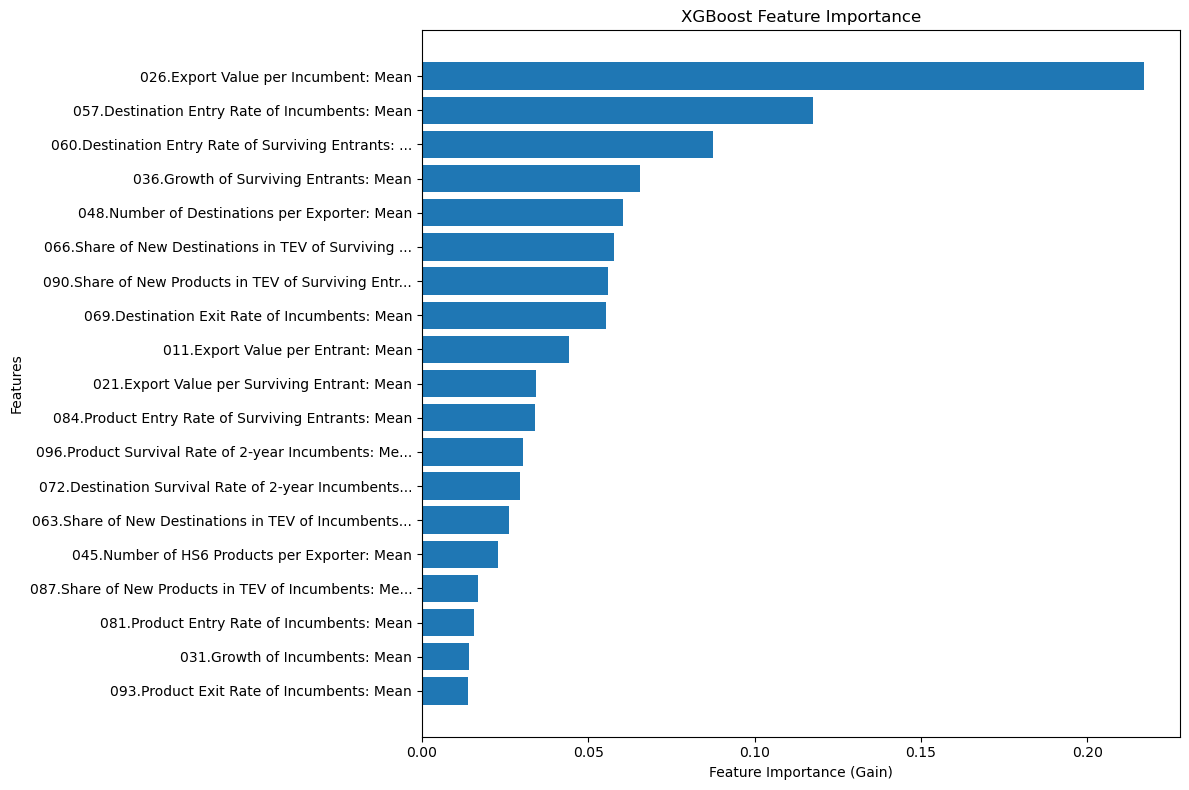


Saved: xgboost_feature_importance.png


In [66]:
# FEATURE IMPORTANCE - XGBoost Built-in
print("="*60)
print("FEATURE IMPORTANCE (XGBoost)")
print("="*60)

# Extract feature importances from XGBoost
feature_importance = pd.DataFrame({
    'feature': predictor_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print("-"*50)
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['importance']:.4f}  {row['feature']}")

# Visualize feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(feature_importance)), feature_importance['importance'].values)
plt.yticks(range(len(feature_importance)), 
           [f[:50] + '...' if len(f) > 50 else f for f in feature_importance['feature'].values])
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: xgboost_feature_importance.png")

In this feature importance graph, we have the export value of incumbent attributing the most importance to the net active export value. This makes sense, since incumbents are the existing exporters that are currently exporting. On top of that, interestingly, the average destination rate of incumbents. This means that the average fraction of already existing incumbents contributes to the net active exports. This signals that new destination markets have a lot of demand and are potential avenues for revenue growth. 

Another interesting finding is the contrast between the feature importance between the growth rate of surviving entrants and the growth rate of incumbents. This could be explained by the fact that the growth rate of incumbents is usually much steadier and stagnant than that of surviving entrants. And if the growth rate is increasing, it's often due to the growth of the surviving entrants. 